## Comparing Measured vs Predicted RMSE Values
We want to be able to see how well our models are at predicting.

We previously calculated the RMSE of repeated measured values after combining 

Number of binding dedup entries that had dups: 7642


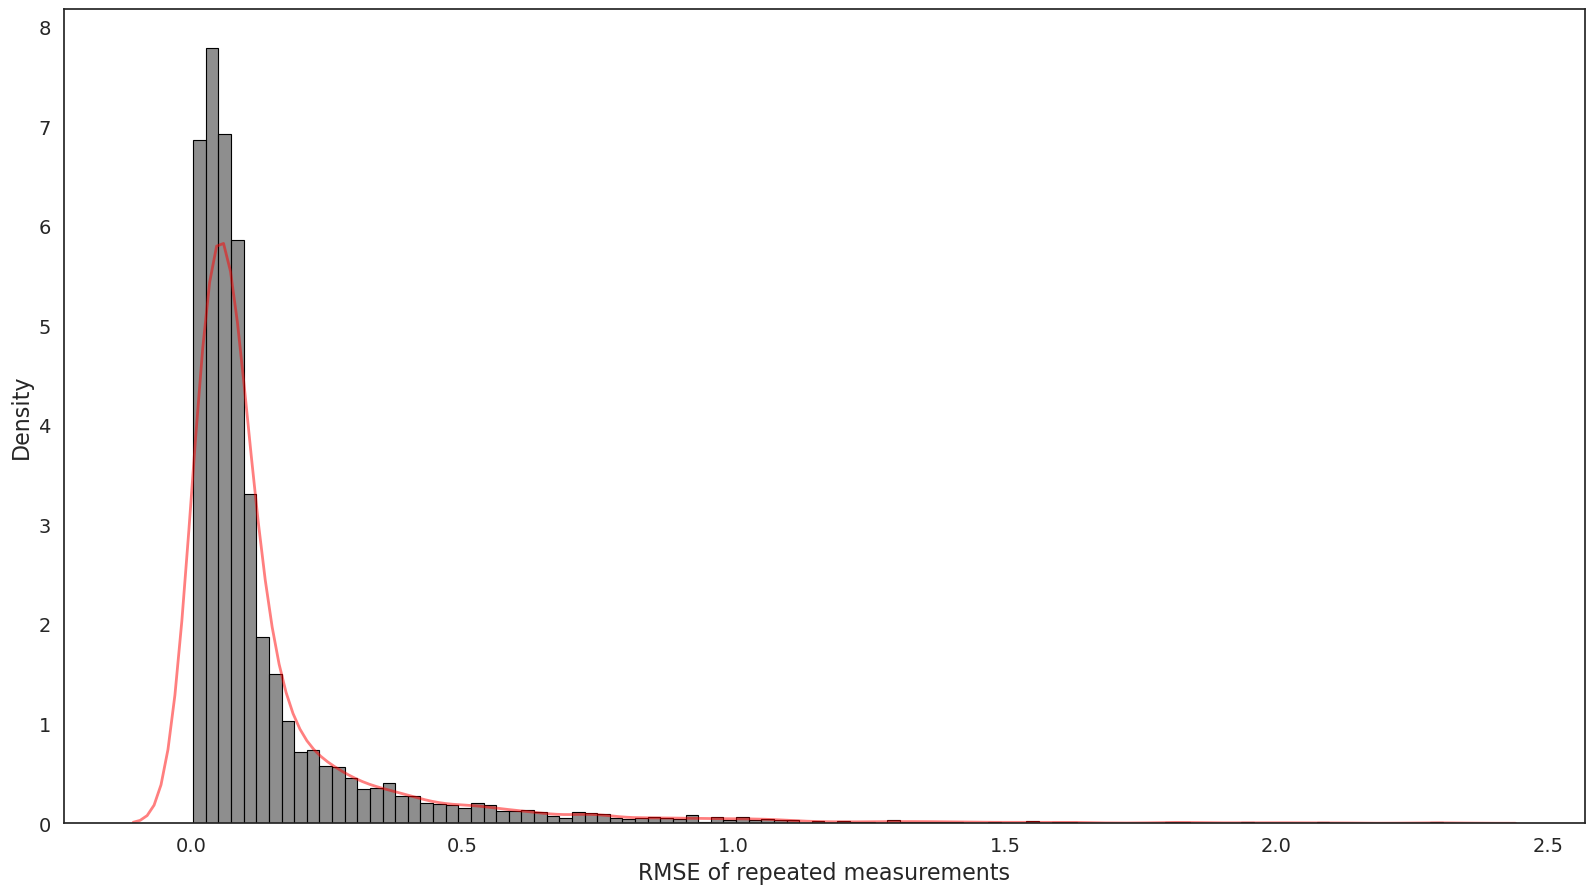

Number of expression dedup entries that had dups: 10441


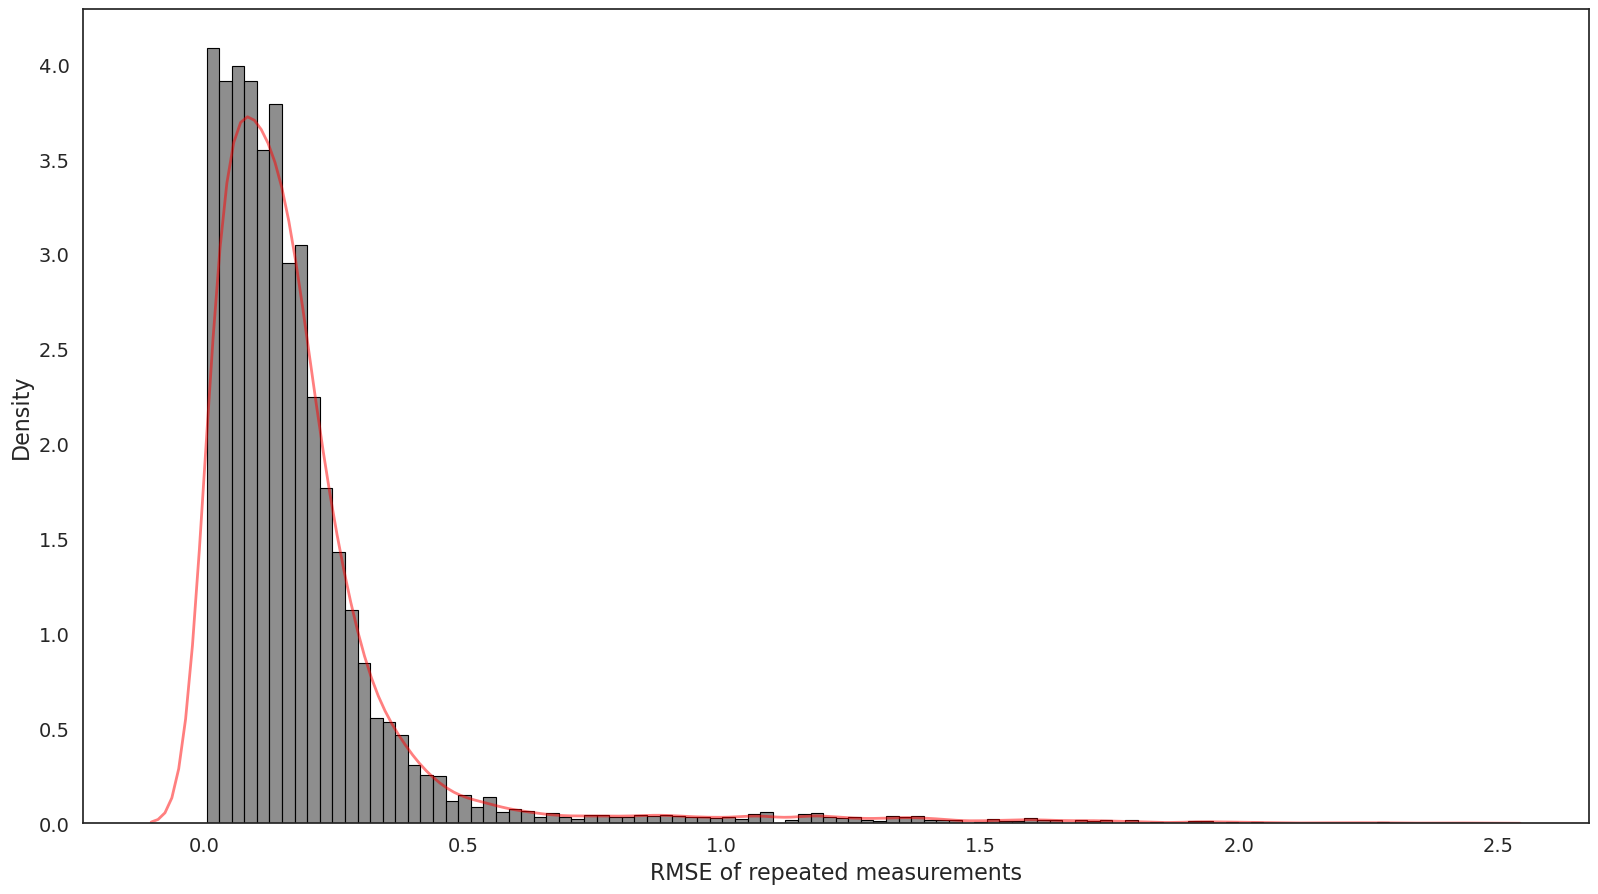

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_value_distribution(df, value_col:str, x_label:str, save_as:str=None):
    """ 
    Plots the given value distribution. 
    """
    sns.set_theme()
    sns.set_context('talk')
    sns.set(style='white')
    plt.figure(figsize=(16, 9))
    plt.rcParams['font.family'] = 'sans-serif'

    # Create histogram and kde plot
    sns.histplot(df[value_col], kde=False, stat='density', bins=100, color='dimgrey', edgecolor='black')
    sns.kdeplot(df[value_col], color='red', linewidth=2, alpha=0.5)

    plt.tight_layout()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel('Density', fontsize=16)
    plt.show()

data_dir = '../../data/dms'
dups_only_b_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
print('Number of binding dedup entries that had dups:', len(dups_only_b_combined_df))
plot_value_distribution(dups_only_b_combined_df, "rmse_binding", "RMSE of repeated measurements")

dups_only_e_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_expression_dups_rmse.csv"), sep=',', header=0)
print('Number of expression dedup entries that had dups:', len(dups_only_e_combined_df))
plot_value_distribution(dups_only_e_combined_df, "rmse_expression", "RMSE of repeated measurements")

Let's try to make a scatterplot that compares these measured pseudo RMSE values with those from our models. 

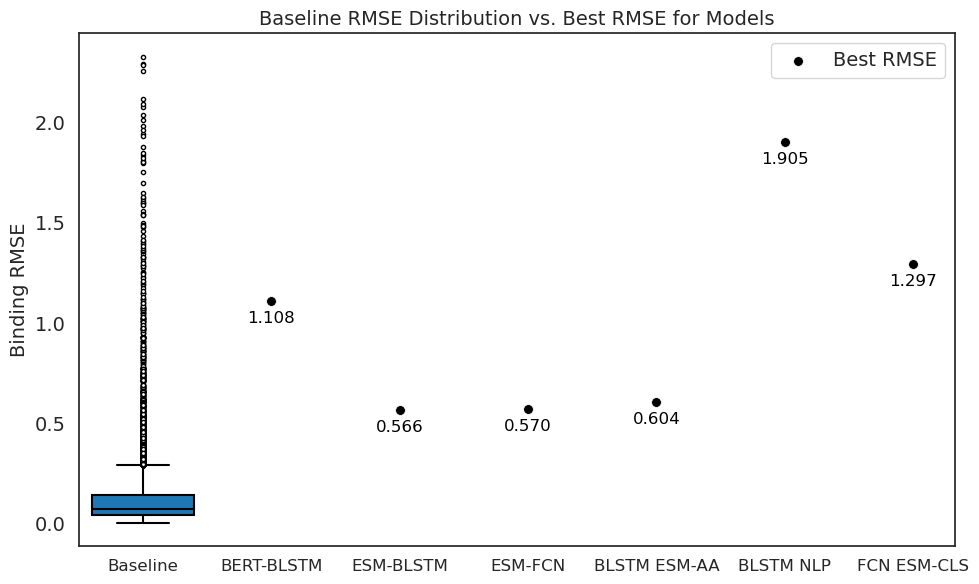

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Load baseline RMSE values
data_dir = '../../data/dms'
baseline_rmse_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
baseline_rmse = baseline_rmse_df['rmse_binding']

# Load model RMSE values over epochs
results_dir = '../../results/run_results'

# Load RMSE values for each model
bert_blstm_df = pd.read_csv(os.path.join(results_dir, "bert_blstm/bert_blstm-DMS_OLD-binding-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_bert_blstm_rmse = bert_blstm_df['Test BLSTM RMSE'].min()

esm_blstm_df = pd.read_csv(os.path.join(results_dir, "esm_blstm/esm_blstm-DMS_OLD-binding-2024-10-22_14-38/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_esm_blstm_rmse = esm_blstm_df['Test RMSE'].min()

esm_fcn_df = pd.read_csv(os.path.join(results_dir, "esm_fcn/esm_fcn-DMS_OLD-binding-2024-10-09_22-50/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_esm_fcn_rmse = esm_fcn_df['Test RMSE'].min()

blstm_esm_aa_df = pd.read_csv(os.path.join(results_dir, "blstm-ESM_AA_preembedded/blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-12_21-02/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_blstm_esm_aa_rmse = blstm_esm_aa_df['Test RMSE'].min()

blstm_nlp_df = pd.read_csv(os.path.join(results_dir, "blstm-NLP/blstm-NLP-DMS_OLD-binding-2024-11-05_16-58/blstm-NLP-DMS_OLD_binding-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_blstm_nlp_rmse = blstm_nlp_df['Test RMSE'].min()

fcn_esm_cls_df = pd.read_csv(os.path.join(results_dir, "fcn-ESM_CLS/fcn-ESM_CLS-DMS_OLD-binding-2024-11-05_17-06/fcn-ESM_CLS-DMS_OLD_binding-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_fcn_esm_cls_rmse = fcn_esm_cls_df['Test RMSE'].min()

# Combine all best model RMSEs into a dictionary
model_rmses = {
    'BERT-BLSTM': best_bert_blstm_rmse,
    'ESM-BLSTM': best_esm_blstm_rmse,
    'ESM-FCN': best_esm_fcn_rmse,
    'BLSTM ESM-AA': best_blstm_esm_aa_rmse,
    'BLSTM NLP': best_blstm_nlp_rmse,
    'FCN ESM-CLS': best_fcn_esm_cls_rmse
}

# Combine all model names and RMSE values
model_names = ['Baseline'] + list(model_rmses.keys())
rmse_values = [None] + list(model_rmses.values())  # Baseline boxplot takes the first position

# Plot the baseline boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=['Baseline'] * len(baseline_rmse),
    y=baseline_rmse,
    showfliers=True,
    boxprops=dict(facecolor='tab:blue', edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='white', markersize=3)
)
# Plot the best RMSE points for models (shifted by 1 for proper alignment)
sns.scatterplot(x=list(range(1, len(model_names))), y=list(model_rmses.values()), color='black', s=50, label='Best RMSE')

# Add labels to the points
for i, value in enumerate(rmse_values[1:]):  # Skip baseline
    plt.text(i + 1, value - 0.05, f'{value:.3f}', ha='center', va='top', color='black')

# Customize the plot
fontsize = 14
plt.title('Baseline RMSE Distribution vs. Best RMSE for Models', fontsize=fontsize)
plt.xticks(ticks=list(range(len(model_names))), labels=model_names, fontsize=fontsize-2)
plt.ylabel('Binding RMSE', fontsize=fontsize)
plt.yticks(fontsize=fontsize)
#plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=fontsize)
plt.tight_layout()
plt.show()

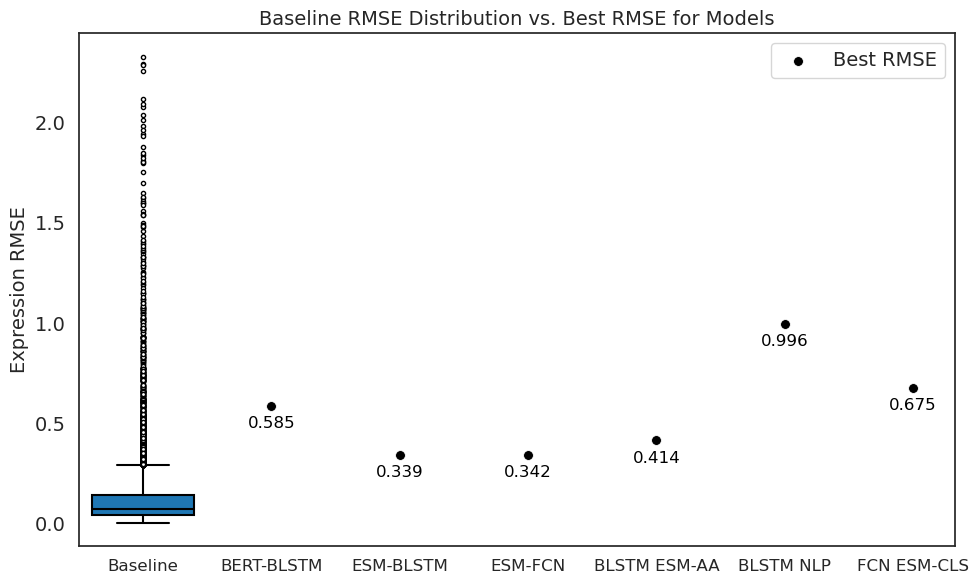

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Load baseline RMSE values
data_dir = '../../data/dms'
baseline_rmse_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
baseline_rmse = baseline_rmse_df['rmse_binding']

# Load model RMSE values over epochs
results_dir = '../../results/run_results'

# Load RMSE values for each model
bert_blstm_df = pd.read_csv(os.path.join(results_dir, "bert_blstm/bert_blstm-DMS_OLD-expression-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_bert_blstm_rmse = bert_blstm_df['Test BLSTM RMSE'].min()

esm_blstm_df = pd.read_csv(os.path.join(results_dir, "esm_blstm/esm_blstm-DMS_OLD-expression-2024-10-22_14-39/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_esm_blstm_rmse = esm_blstm_df['Test RMSE'].min()

esm_fcn_df = pd.read_csv(os.path.join(results_dir, "esm_fcn/esm_fcn-DMS_OLD-expression-2024-10-09_22-51/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_esm_fcn_rmse = esm_fcn_df['Test RMSE'].min()

blstm_esm_aa_df = pd.read_csv(os.path.join(results_dir, "blstm-ESM_AA_preembedded/blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-12_20-57/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_blstm_esm_aa_rmse = blstm_esm_aa_df['Test RMSE'].min()

blstm_nlp_df = pd.read_csv(os.path.join(results_dir, "blstm-NLP/blstm-NLP-DMS_OLD-expression-2024-11-05_16-58/blstm-NLP-DMS_OLD_expression-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_blstm_nlp_rmse = blstm_nlp_df['Test RMSE'].min()

fcn_esm_cls_df = pd.read_csv(os.path.join(results_dir, "fcn-ESM_CLS/fcn-ESM_CLS-DMS_OLD-expression-2024-11-05_17-05/fcn-ESM_CLS-DMS_OLD_expression-train_82178_test_20545_metrics.csv"), sep=',', header=0)
best_fcn_esm_cls_rmse = fcn_esm_cls_df['Test RMSE'].min()

# Combine all best model RMSEs into a dictionary
model_rmses = {
    'BERT-BLSTM': best_bert_blstm_rmse,
    'ESM-BLSTM': best_esm_blstm_rmse,
    'ESM-FCN': best_esm_fcn_rmse,
    'BLSTM ESM-AA': best_blstm_esm_aa_rmse,
    'BLSTM NLP': best_blstm_nlp_rmse,
    'FCN ESM-CLS': best_fcn_esm_cls_rmse
}

# Combine all model names and RMSE values
model_names = ['Baseline'] + list(model_rmses.keys())
rmse_values = [None] + list(model_rmses.values())  # Baseline boxplot takes the first position

# Plot the baseline boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=['Baseline'] * len(baseline_rmse),
    y=baseline_rmse,
    showfliers=True,
    boxprops=dict(facecolor='tab:blue', edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='white', markersize=3)
)
# Plot the best RMSE points for models (shifted by 1 for proper alignment)
sns.scatterplot(x=list(range(1, len(model_names))), y=list(model_rmses.values()), color='black', s=50, label='Best RMSE')

# Add labels to the points
for i, value in enumerate(rmse_values[1:]):  # Skip baseline
    plt.text(i + 1, value - 0.05, f'{value:.3f}', ha='center', va='top', color='black')

# Customize the plot
fontsize = 14
plt.title('Baseline RMSE Distribution vs. Best RMSE for Models', fontsize=fontsize)
plt.xticks(ticks=list(range(len(model_names))), labels=model_names, fontsize=fontsize-2)
plt.ylabel('Expression RMSE', fontsize=fontsize)
plt.yticks(fontsize=fontsize)
#plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=fontsize)
plt.tight_layout()
plt.show()